In [23]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,f1_score
import joblib

In [2]:
df=pd.read_csv('Churn_Modelling.csv')
print(f"\n\nthe rows and columns in dataset are {df.shape}\n\n")
print(f"\n\nthe number of duplicated rows are {df.duplicated().sum()}\n\n")
df.head()



the rows and columns in dataset are (10000, 14)




the number of duplicated rows are 0




,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print(df.isna().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [6]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
print(pd.unique(df['Geography']))
print(pd.unique(df['Gender']))

['France' 'Spain' 'Germany']
['Female' 'Male']


In [8]:
le=LabelEncoder()
ohe=OneHotEncoder(drop='first',handle_unknown='ignore',sparse_output=False)
x=df.drop(['Exited'],axis=1)
y=df['Exited']

In [9]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=40)

In [10]:
x_train['Gender']=le.fit_transform(x_train['Gender'])
x_test['Gender']=le.transform(x_test['Gender'])

In [11]:
x_train.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
1309,591,Spain,1,30,8,124857.69,2,0,0,50485.70
8016,569,Spain,1,41,2,0.00,2,1,0,134272.57
2795,515,France,0,25,7,79543.59,1,0,1,38772.82
9227,776,France,0,31,5,0.00,2,1,0,92647.94
7094,640,France,0,67,3,0.00,1,0,1,42964.63


In [12]:
encoded_train=ohe.fit_transform(x_train[['Geography']])
encoded_test=ohe.transform(x_test[['Geography']])

In [13]:
encoded_train=pd.DataFrame(encoded_train,columns=ohe.get_feature_names_out(),index=x_train.index)
encoded_test=pd.DataFrame(encoded_test,columns=ohe.get_feature_names_out(),index=x_test.index)

In [14]:
x_train=x_train.drop('Geography',axis=1)
x_test=x_test.drop('Geography',axis=1)
x_train=pd.concat([x_train,encoded_train],axis=1)
x_test=pd.concat([x_test,encoded_test],axis=1)

In [15]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [16]:
model=Sequential()
model.add(Dense(11,activation='relu',input_dim=11))
model.add(Dense(7,activation="relu"))
model.add(Dense(1,activation="sigmoid"))

C:\Users\bhuwa\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 11)             │           132 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │            84 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224 (896.00 B)

 Trainable params: 224 (896.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
model.compile(loss="binary_crossentropy",optimizer='Adam',metrics=['accuracy'])
history=model.fit(x_train_scaled,y_train,epochs=100,validation_split=0.2)


Epoch 1/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7568 - loss: 0.5445 - val_accuracy: 0.8186 - val_loss: 0.4505
Epoch 2/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7907 - loss: 0.4722 - val_accuracy: 0.8186 - val_loss: 0.4261
Epoch 3/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7916 - loss: 0.4538 - val_accuracy: 0.8193 - val_loss: 0.4160
Epoch 4/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7929 - loss: 0.4438 - val_accuracy: 0.8221 - val_loss: 0.4116
Epoch 5/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7950 - loss: 0.4366 - val_accuracy: 0.8271 - val_loss: 0.4073
Epoch 6/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7980 - loss: 0.4302 - val_accuracy: 0.8271 - val_loss: 0.4016
Epoch 7/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8014 - loss: 0.4235 - val_accuracy: 0.8271 - val_loss: 0.3949
Epoch 8/100
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8062 - loss: 0.4161 - val_accu

In [19]:
y_pred=model.predict(x_test_scaled)
y_pred=np.where(y_pred>0.5,1,0)


94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  


In [20]:
print(accuracy_score(y_test,y_pred))

0.8536666666666667


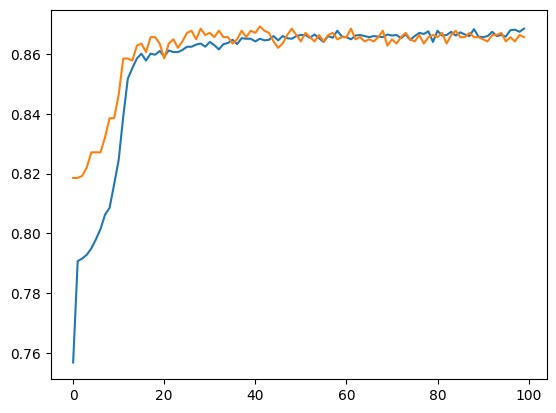

In [21]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

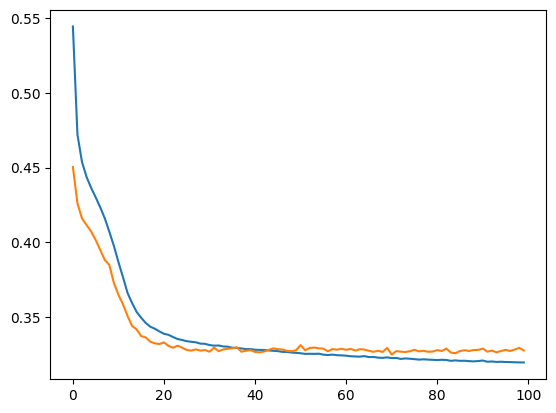

In [22]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])